# 🎬 Sentiment Analysis on IMDB Movie Reviews
### NLP Course Final Project

**Pipeline:**
1. Load & Explore Data (EDA)
2. Preprocessing
3. Baseline Model: TF-IDF + Logistic Regression
4. Deep Learning: LSTM
5. Transformer: BERT Fine-tuning
6. Evaluation & Comparison



## 📦 1. Install & Import Libraries

In [ ]:
# Install required libraries
!pip install datasets transformers torch scikit-learn matplotlib seaborn wordcloud nltk accelerate -q

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print('Libraries imported successfully!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries imported successfully!


## 📂 2. Load IMDB Dataset

In [4]:
from datasets import load_dataset

# Load IMDB dataset from HuggingFace (50k reviews)
dataset = load_dataset('stanfordnlp/imdb')

# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

# 0 = Negative, 1 = Positive
train_df['sentiment'] = train_df['label'].map({0: 'negative', 1: 'positive'})
test_df['sentiment']  = test_df['label'].map({0: 'negative', 1: 'positive'})

print(f'Train size: {len(train_df):,}')
print(f'Test size:  {len(test_df):,}')
train_df.head(3)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25,000
Test size:  25,000


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative


## 📊 3. Exploratory Data Analysis (EDA)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       25000 non-null  object
 1   label      25000 non-null  int64 
 2   sentiment  25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


In [6]:
train_df.isnull().sum()

,0
text,0
label,0
sentiment,0


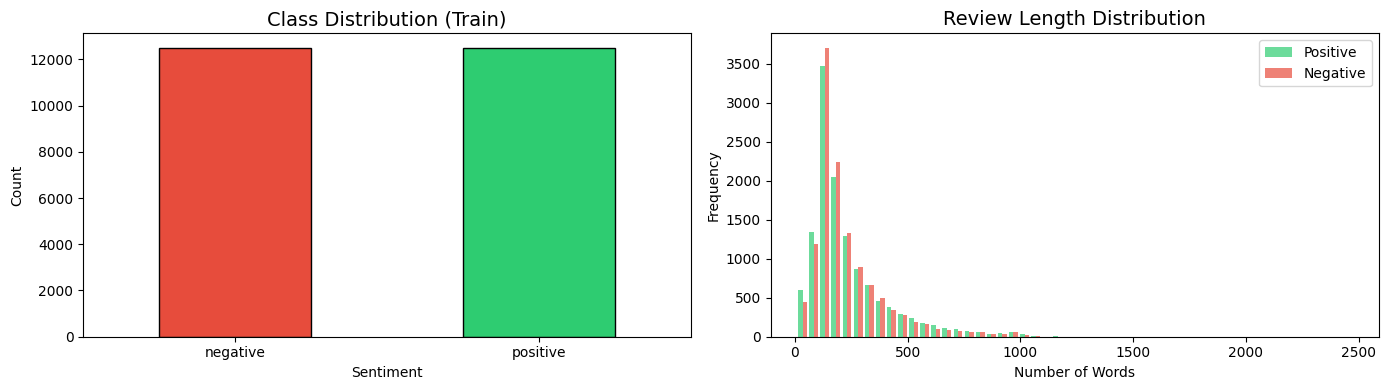

Average review length: 234 words
Max review length:     2470 words


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class Distribution
train_df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Class Distribution (Train)', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Review Length Distribution
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))
axes[1].hist(
    [train_df[train_df['label']==1]['review_length'],
     train_df[train_df['label']==0]['review_length']],
    bins=50, label=['Positive', 'Negative'],
    color=['#2ecc71', '#e74c3c'], alpha=0.7
)
axes[1].set_title('Review Length Distribution', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average review length: {train_df['review_length'].mean():.0f} words")
print(f"Max review length:     {train_df['review_length'].max()} words")

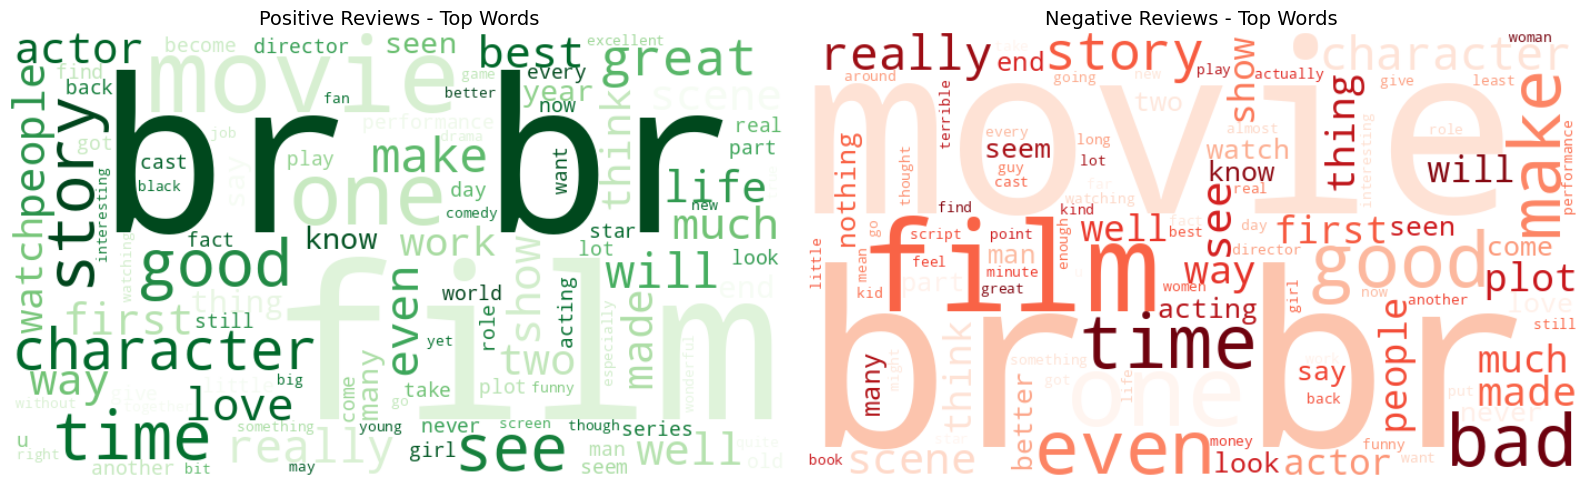

In [8]:
# WordCloud for Positive Reviews
pos_text = ' '.join(train_df[train_df['label'] == 1]['text'].head(500))
neg_text = ' '.join(train_df[train_df['label'] == 0]['text'].head(500))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Top Words', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Top Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 🧹 4. Text Preprocessing

In [11]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and normalize text for classical ML models."""
    # Lowercase
    text = text.lower()
    # Remove HTML tags (common in IMDB)
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Preprocessing train set...')
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
print('Preprocessing test set...')
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

print('\n Done!')
print('\nOriginal:', train_df['text'].iloc[0][:200])
print('\nCleaned: ', train_df['clean_text'].iloc[0][:200])

Preprocessing train set...
Preprocessing test set...

 Done!

Original: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

Cleaned:  rented curiousyellow video store controversy surrounded first released also heard first seized customs ever tried enter country therefore fan films considered controversial really see myselfthe plot c


## 🤖 5. Baseline Model — TF-IDF + Logistic Regression

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

y_train = train_df['label'].values
y_test  = test_df['label'].values

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

# Predict & Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 0.8876 (88.76%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     12500
    Positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



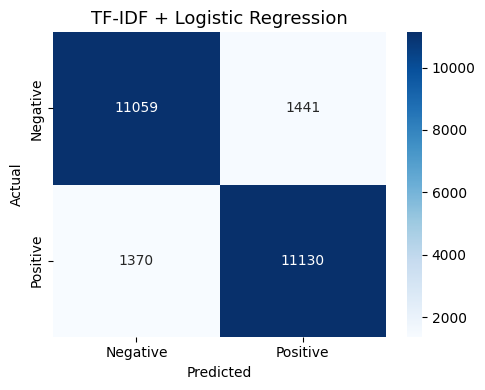

In [13]:
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_confusion_matrix(y_test, y_pred_lr, 'TF-IDF + Logistic Regression', ax)
plt.tight_layout()
plt.show()

In [14]:
def predict_sentiment(review):
    # تنظيف النص
    clean_review = preprocess_text(review)

    # تحويله إلى TF-IDF
    review_vector = tfidf.transform([clean_review])

    # التنبؤ
    prediction = lr_model.predict(review_vector)[0]

    # نسبة الثقة
    probability = lr_model.predict_proba(review_vector)[0]

    if prediction == 1:
        sentiment = "Positive 😊"
        confidence = probability[1]
    else:
        sentiment = "Negative 😞"
        confidence = probability[0]

    print(f"Review: {review}")
    print(f"Prediction: {sentiment}")
    print(f"Confidence: {confidence:.2%}")

In [17]:
predict_sentiment("This movie was amazing. I loved it very much .")

Review: This movie was amazing. I loved it very much 323.
Prediction: Positive 😊
Confidence: 92.23%


In [18]:
predict_sentiment("This movie was terrible. It was boring and a waste of time.")

Review: This movie was terrible. It was boring and a waste of time.
Prediction: Negative 😞
Confidence: 99.96%


## 🧠 6. BERT Fine-tuning (State-of-the-art)

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [29]:
# ─── Dataset Class ───────────────────────────────────────────────────────────
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ─── Load Tokenizer ──────────────────────────────────────────────────────────
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)

TRAIN_SAMPLES = 25000
TEST_SAMPLES  = 25000

train_subset = train_df.sample(TRAIN_SAMPLES, random_state=42)
test_subset  = test_df.sample(TEST_SAMPLES,  random_state=42)

train_dataset = IMDBDataset(
    train_subset['text'].tolist(),
    train_subset['label'].tolist(),
    tokenizer
)
test_dataset = IMDBDataset(
    test_subset['text'].tolist(),
    test_subset['label'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 1563 | Test batches: 1563


In [30]:
# ─── Load BERT Model ─────────────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)
model = model.to(device)

# ─── Optimizer & Scheduler ───────────────────────────────────────────────────
EPOCHS       = 3
optimizer    = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 4689


In [32]:
# ─── Training Loop ───────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)


# ─── Run Training ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_preds, val_labels = evaluate(model, test_loader, device)
    val_acc               = accuracy_score(val_labels, val_preds)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'Loss: {train_loss:.4f} | '
          f'Train Acc: {train_acc:.4f} | '
          f'Val Acc: {val_acc:.4f}')

bert_acc = history['val_acc'][-1]
print(f'\n BERT Final Accuracy: {bert_acc:.4f} ({bert_acc*100:.2f}%)')

Epoch 1/3 — Loss: 0.0627 | Train Acc: 0.9850 | Val Acc: 0.9217
Epoch 2/3 — Loss: 0.0631 | Train Acc: 0.9854 | Val Acc: 0.9217
Epoch 3/3 — Loss: 0.0610 | Train Acc: 0.9855 | Val Acc: 0.9217

 BERT Final Accuracy: 0.9217 (92.17%)


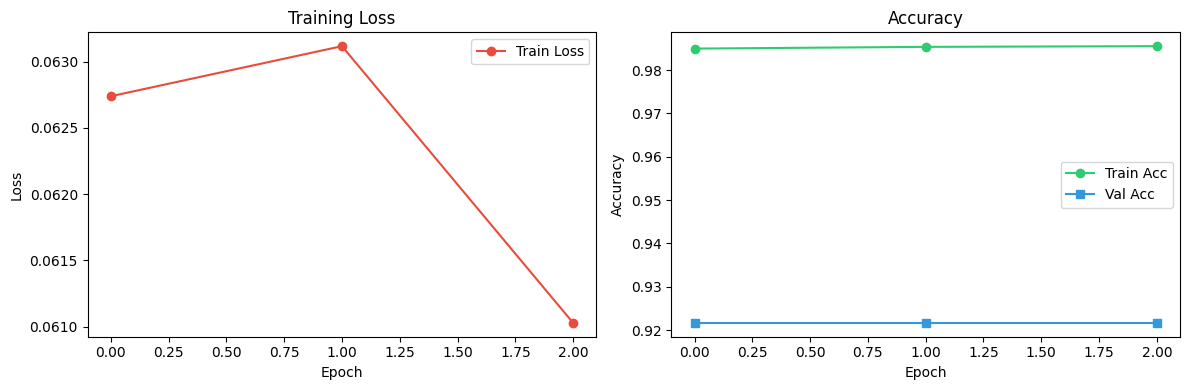

In [ ]:
# ─── Training Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], marker='o', color='#e74c3c', label='Train Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], marker='o', color='#2ecc71', label='Train Acc')
axes[1].plot(history['val_acc'],   marker='s', color='#3498db', label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred_bert, y_true_bert = evaluate(model, test_loader, device)
print('\nBERT Classification Report:')
print(classification_report(y_true_bert, y_pred_bert, target_names=['Negative', 'Positive']))

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(y_true_bert, y_pred_bert, 'BERT Fine-tuned', ax)
plt.tight_layout()
plt.show()

## 📊 7. Model Comparison

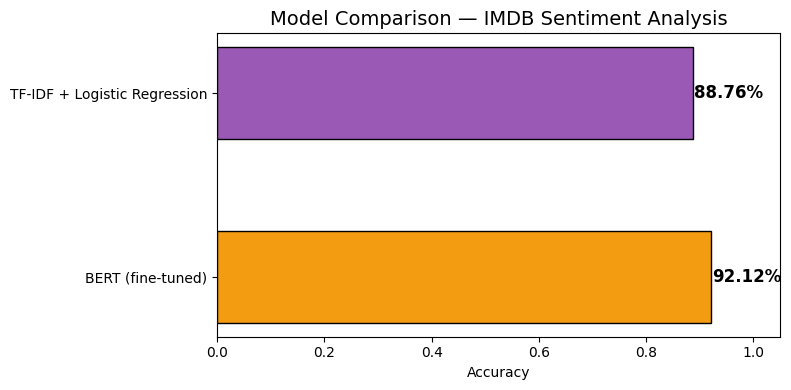

                       Model  Accuracy
           BERT (fine-tuned)   0.92120
TF-IDF + Logistic Regression   0.88756


In [26]:
results = {
    'Model': ['TF-IDF + Logistic Regression', 'BERT (fine-tuned)'],
    'Accuracy': [lr_acc, bert_acc]
}
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    results_df['Model'], results_df['Accuracy'],
    color=['#f39c12', '#9b59b6'],
    edgecolor='black', height=0.5
)
for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
        f'{acc*100:.2f}%', va='center', fontsize=12, fontweight='bold'
    )
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — IMDB Sentiment Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## 💾 8. Save Models

In [27]:
import pickle, os

os.makedirs('saved_models', exist_ok=True)

# Save Baseline
with open('saved_models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('saved_models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save BERT
model.save_pretrained('saved_models/bert_sentiment')
tokenizer.save_pretrained('saved_models/bert_sentiment')

print(' All models saved to saved_models/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 All models saved to saved_models/


---
## ✅ Project Summary

| Step | Description | Status |
|------|-------------|--------|
| Data Loading | IMDB 50k reviews from HuggingFace | ✅ |
| EDA | Class distribution, length, WordCloud | ✅ |
| Preprocessing | Clean, tokenize, remove stopwords | ✅ |
| Baseline | TF-IDF + Logistic Regression | ✅ |
| BERT | Fine-tuned bert-base-uncased | ✅ |
| Evaluation | Accuracy, F1, Confusion Matrix | ✅ |
| Comparison | All models side by side | ✅ |
| Save Models | Pickle + HuggingFace format | ✅ |

